In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn import feature_extraction, linear_model, model_selection, preprocessing
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [5]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

In [6]:
fake.shape

(23481, 4)

In [7]:
true.shape

(21417, 4)

In [8]:
# Add flag to track fake and real
fake['target'] = 'fake'
true['target'] = 'true'

In [9]:

# Concatenate dataframes
data = pd.concat([fake, true]).reset_index(drop = True)
data.shape

(44898, 5)

In [10]:

# Shuffle the data
from sklearn.utils import shuffle
data = shuffle(data)
data = data.reset_index(drop=True)

In [11]:
# Check the data
data.head()

,title,text,subject,date,target
0,Trump's USTR nominee pledges tough enforcement...,WASHINGTON (Reuters) - President Donald Trump’...,politicsNews,"March 14, 2017",true
1,Billionaire Liberal Governor Boosted State’s ...,Many Republicans often argue raising the minim...,News,"March 13, 2016",fake
2,"After London setback, May wins Brexit cheer in...",BRUSSELS (Reuters) - British Prime Minister Th...,worldnews,"December 14, 2017",true
3,White House budget director: unclear if House ...,WASHINGTON (Reuters) - White House budget dire...,politicsNews,"March 24, 2017",true
4,PATRIOT CALL TO ACTION: A Major Storm Is Brewi...,This is a call to action You guys always talk...,Government News,"Dec 30, 2015",fake


In [12]:
# Removing the date (we won't use it for the analysis)
data.drop(["date"],axis=1,inplace=True)
data.head()

,title,text,subject,target
0,Trump's USTR nominee pledges tough enforcement...,WASHINGTON (Reuters) - President Donald Trump’...,politicsNews,true
1,Billionaire Liberal Governor Boosted State’s ...,Many Republicans often argue raising the minim...,News,fake
2,"After London setback, May wins Brexit cheer in...",BRUSSELS (Reuters) - British Prime Minister Th...,worldnews,true
3,White House budget director: unclear if House ...,WASHINGTON (Reuters) - White House budget dire...,politicsNews,true
4,PATRIOT CALL TO ACTION: A Major Storm Is Brewi...,This is a call to action You guys always talk...,Government News,fake


In [13]:
# Removing the title (we will only use the text)
data.drop(["title"],axis=1,inplace=True)
data.head()

,text,subject,target
0,WASHINGTON (Reuters) - President Donald Trump’...,politicsNews,true
1,Many Republicans often argue raising the minim...,News,fake
2,BRUSSELS (Reuters) - British Prime Minister Th...,worldnews,true
3,WASHINGTON (Reuters) - White House budget dire...,politicsNews,true
4,This is a call to action You guys always talk...,Government News,fake


In [14]:
# Convert to lowercase

data['text'] = data['text'].apply(lambda x: x.lower())
data.head()

,text,subject,target
0,washington (reuters) - president donald trump’...,politicsNews,true
1,many republicans often argue raising the minim...,News,fake
2,brussels (reuters) - british prime minister th...,worldnews,true
3,washington (reuters) - white house budget dire...,politicsNews,true
4,this is a call to action you guys always talk...,Government News,fake


In [15]:
# Remove punctuation

import string

def punctuation_removal(text):
    all_list = [char for char in text if char not in string.punctuation]
    clean_str = ''.join(all_list)
    return clean_str

data['text'] = data['text'].apply(punctuation_removal)

In [16]:
# Check
data.head()

,text,subject,target
0,washington reuters president donald trump’s c...,politicsNews,true
1,many republicans often argue raising the minim...,News,fake
2,brussels reuters british prime minister there...,worldnews,true
3,washington reuters white house budget directo...,politicsNews,true
4,this is a call to action you guys always talk...,Government News,fake


In [17]:
# Removing stopwords
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop = stopwords.words('english')

data['text'] = data['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [18]:
data.head()

,text,subject,target
0,washington reuters president donald trump’s ch...,politicsNews,true
1,many republicans often argue raising minimum w...,News,fake
2,brussels reuters british prime minister theres...,worldnews,true
3,washington reuters white house budget director...,politicsNews,true
4,call action guys always talk getting couch som...,Government News,fake



# ***Basic data exploration***

subject
Government News     1570
Middle-east          778
News                9050
US_News              783
left-news           4459
politics            6841
politicsNews       11272
worldnews          10145
Name: text, dtype: int64


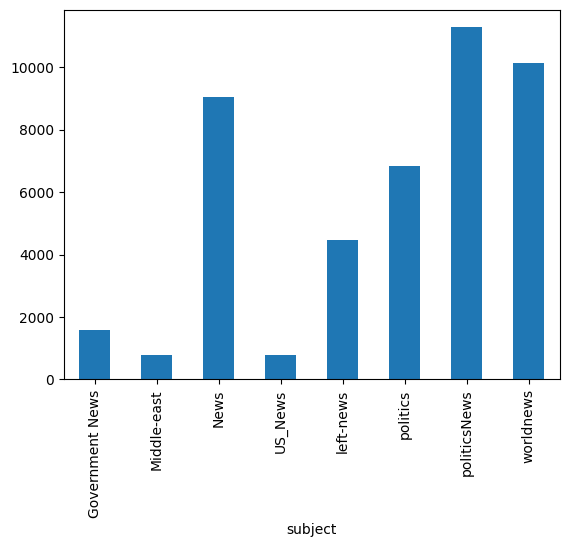

In [19]:
# How many articles per subject?
print(data.groupby(['subject'])['text'].count())
data.groupby(['subject'])['text'].count().plot(kind="bar")
plt.show()

target
fake    23481
true    21417
Name: text, dtype: int64


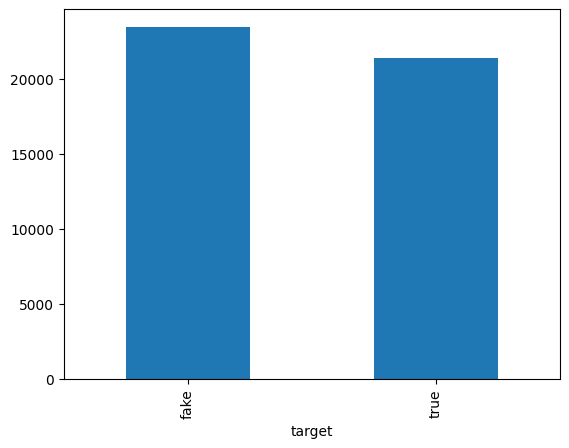

In [20]:
# How many fake and real articles?
print(data.groupby(['target'])['text'].count())
data.groupby(['target'])['text'].count().plot(kind="bar")
plt.show()

# ***Generating Word Cloud for Fake News Articles***

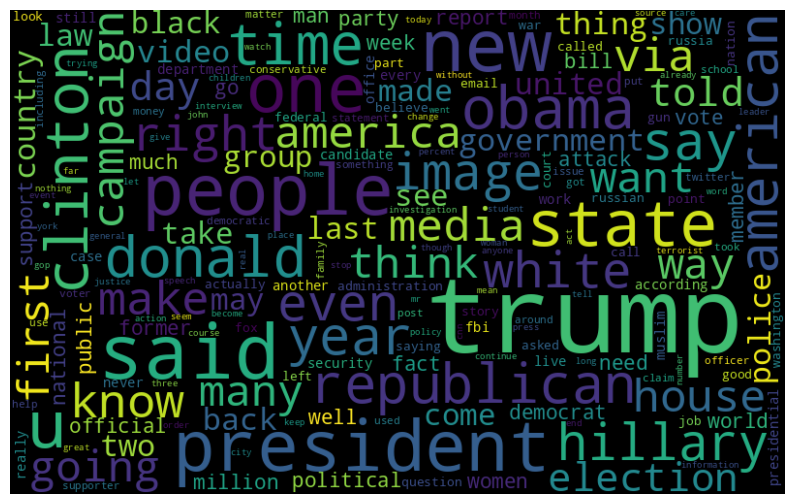

In [21]:
# Word cloud for fake news
from wordcloud import WordCloud

fake_data = data[data["target"] == "fake"]
all_words = ' '.join([text for text in fake_data.text])

wordcloud = WordCloud(width= 800, height= 500,
                          max_font_size = 110,
                          collocations = False).generate(all_words)

plt.figure(figsize=(10,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

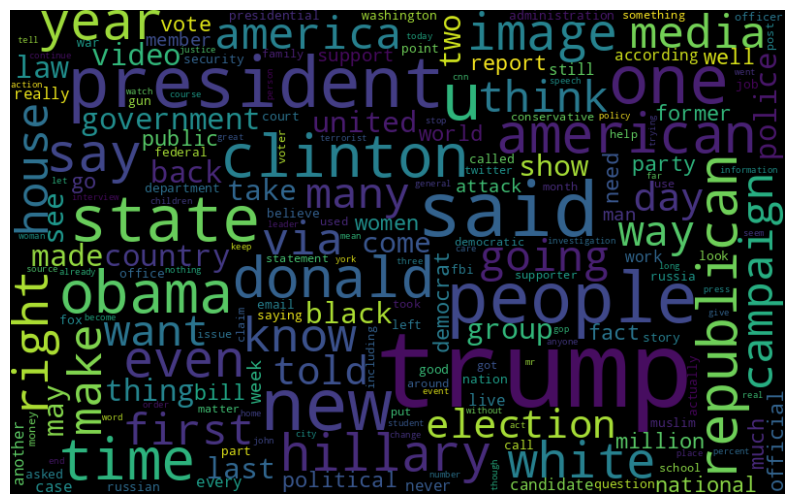

In [22]:
# Word cloud for real news
from wordcloud import WordCloud

real_data = data[data["target"] == "true"]
all_words = ' '.join([text for text in fake_data.text])

wordcloud = WordCloud(width= 800, height= 500,
                          max_font_size = 110,
                          collocations = False).generate(all_words)

plt.figure(figsize=(10,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


In [23]:
# Most frequent words counter (Code adapted from https://www.kaggle.com/rodolfoluna/fake-news-detector)
from nltk import tokenize

token_space = tokenize.WhitespaceTokenizer()

def counter(text, column_text, quantity):
    all_words = ' '.join([text for text in text[column_text]])
    token_phrase = token_space.tokenize(all_words)
    frequency = nltk.FreqDist(token_phrase)
    df_frequency = pd.DataFrame({"Word": list(frequency.keys()),
                                   "Frequency": list(frequency.values())})
    df_frequency = df_frequency.nlargest(columns = "Frequency", n = quantity)
    plt.figure(figsize=(12,8))
    ax = sns.barplot(data = df_frequency, x = "Word", y = "Frequency", color = 'blue')
    ax.set(ylabel = "Count")
    plt.xticks(rotation='vertical')
    plt.show()

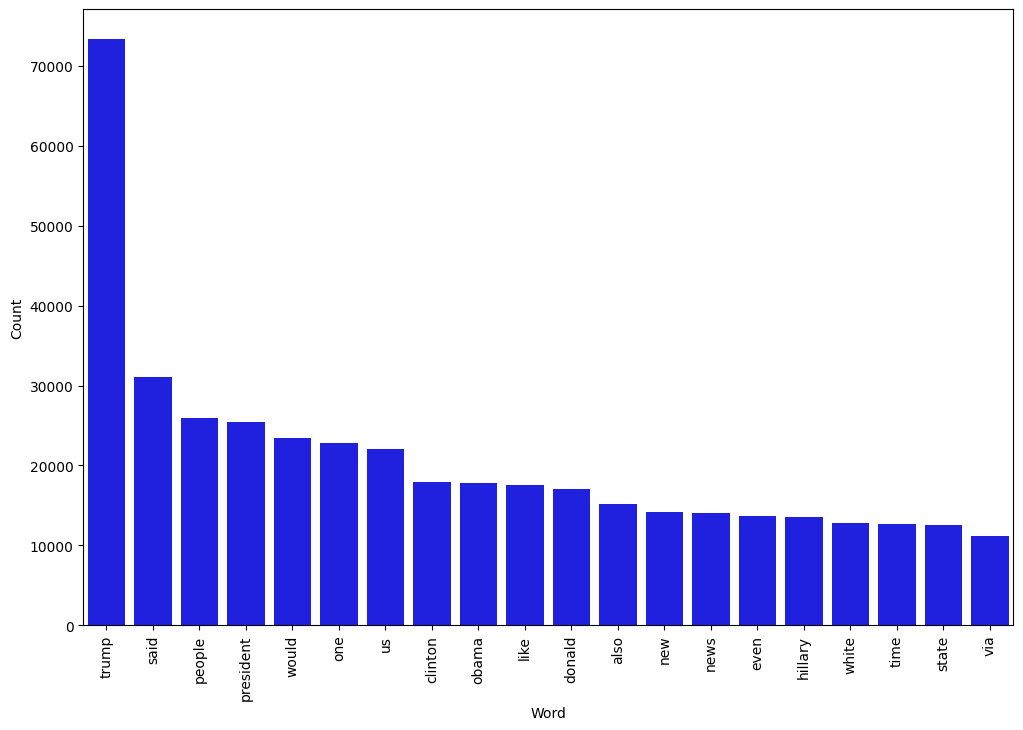

In [24]:
# Most frequent words in fake news
counter(data[data["target"] == "fake"], "text", 20)

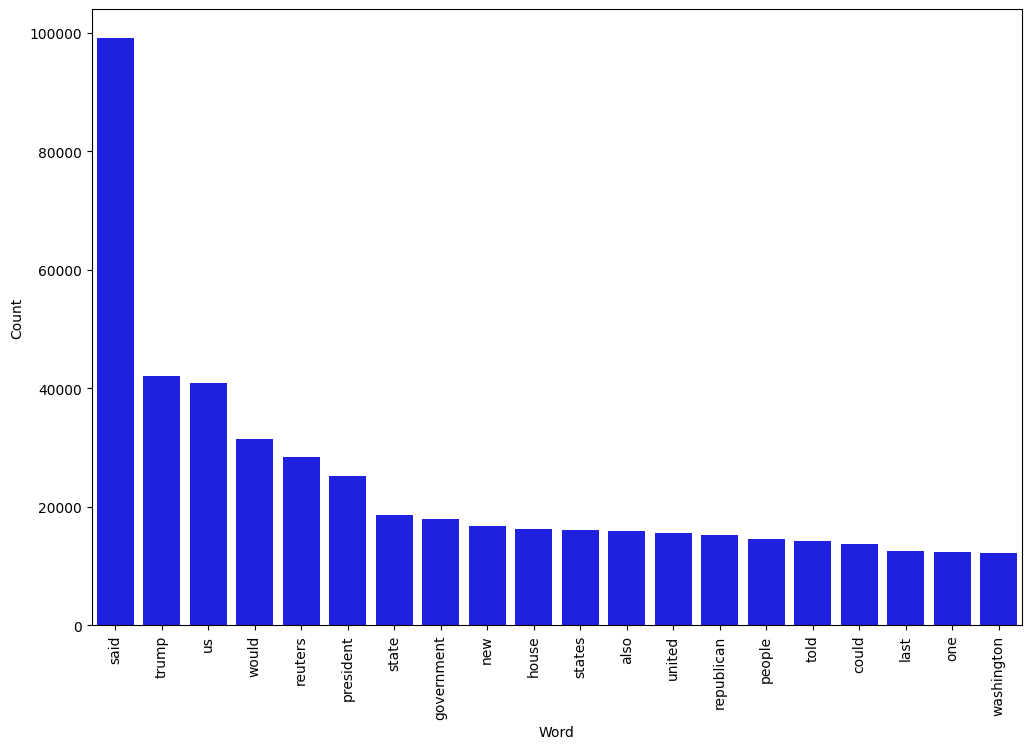

In [25]:
# Most frequent words in real news
counter(data[data["target"] == "true"], "text", 20)

In [26]:
# Function to plot the confusion matrix (code from https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html)
from sklearn import metrics
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# ***Splitting the dataset into training and testing sets***

In [27]:
# Split the data
X_train,X_test,y_train,y_test = train_test_split(data['text'], data.target, test_size=0.2, random_state=42)

# **Logistic** **regression**

In [40]:
# Vectorizing and applying TF-IDF
from sklearn.linear_model import LogisticRegression

# Vectorizing and applying TF-IDF with Logistic Regression
pipe = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer()),
    ('model', LogisticRegression(random_state=42))
])

# Fitting the model
model = pipe.fit(X_train, y_train)

# Predictions
prediction = model.predict(X_test)

# Print model name + metrics
print("🔹 Model: LogisticRegression\n")
print("Accuracy : {}%".format(round(accuracy_score(y_test, prediction)*100, 2)))
print("Precision: {}%".format(round(precision_score(y_test, prediction, average='weighted')*100, 2)))
print("Recall   : {}%".format(round(recall_score(y_test, prediction, average='weighted')*100, 2)))
print("F1 Score : {}%".format(round(f1_score(y_test, prediction, average='weighted')*100, 2)))


🔹 Model: LogisticRegression

Accuracy : 98.88%
Precision: 98.88%
Recall   : 98.88%
F1 Score : 98.88%


Confusion matrix, without normalization


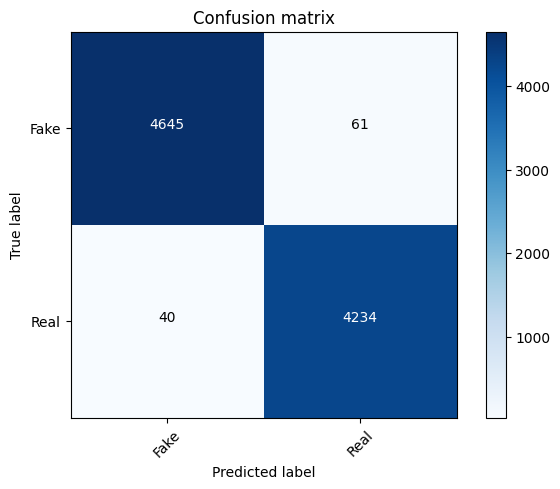

In [30]:
cm = metrics.confusion_matrix(y_test, prediction)
plot_confusion_matrix(cm, classes=['Fake', 'Real'])

# ***Decision Tree Classifier***

In [36]:
from sklearn.tree import DecisionTreeClassifier

# Vectorizing and applying TF-IDF
pipe = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer()),
    ('model', DecisionTreeClassifier(criterion='entropy',
                                     max_depth=20,
                                     splitter='best',
                                     random_state=42))
])

# Fitting the model
model = pipe.fit(X_train, y_train)

# Predictions
prediction = model.predict(X_test)

# Print model name + metrics
print("🔹 Model: DecisionTreeClassifier\n")
print("Accuracy : {}%".format(round(accuracy_score(y_test, prediction)*100, 2)))
print("Precision: {}%".format(round(precision_score(y_test, prediction, average='weighted')*100, 2)))
print("Recall   : {}%".format(round(recall_score(y_test, prediction, average='weighted')*100, 2)))
print("F1 Score : {}%".format(round(f1_score(y_test, prediction, average='weighted')*100, 2)))


🔹 Model: DecisionTreeClassifier

Accuracy : 99.71%
Precision: 99.71%
Recall   : 99.71%
F1 Score : 99.71%


Confusion matrix, without normalization


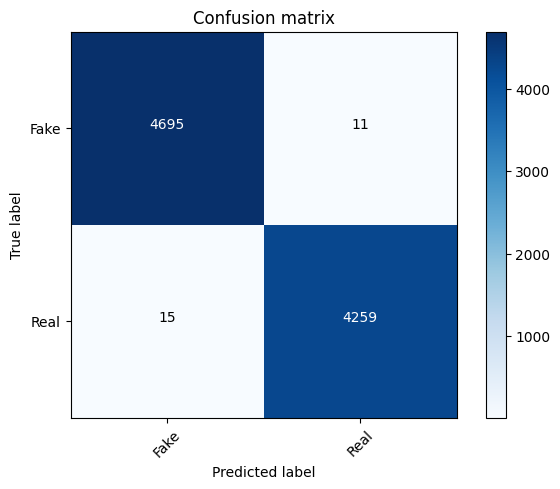

In [37]:
cm = metrics.confusion_matrix(y_test, prediction)
plot_confusion_matrix(cm, classes=['Fake', 'Real'])

# ***Random Forest Classifier***


In [38]:
from sklearn.ensemble import RandomForestClassifier

# Vectorizing and applying TF-IDF with Random Forest
pipe = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer()),
    ('model', RandomForestClassifier(n_estimators=50, criterion="entropy", random_state=42))
])

# Fitting the model
model = pipe.fit(X_train, y_train)

# Predictions
prediction = model.predict(X_test)

# Print model name + metrics
print("🔹 Model: RandomForestClassifier\n")
print("Accuracy : {}%".format(round(accuracy_score(y_test, prediction)*100, 2)))
print("Precision: {}%".format(round(precision_score(y_test, prediction, average='weighted')*100, 2)))
print("Recall   : {}%".format(round(recall_score(y_test, prediction, average='weighted')*100, 2)))
print("F1 Score : {}%".format(round(f1_score(y_test, prediction, average='weighted')*100, 2)))


🔹 Model: RandomForestClassifier

Accuracy : 98.99%
Precision: 98.99%
Recall   : 98.99%
F1 Score : 98.99%


Confusion matrix, without normalization


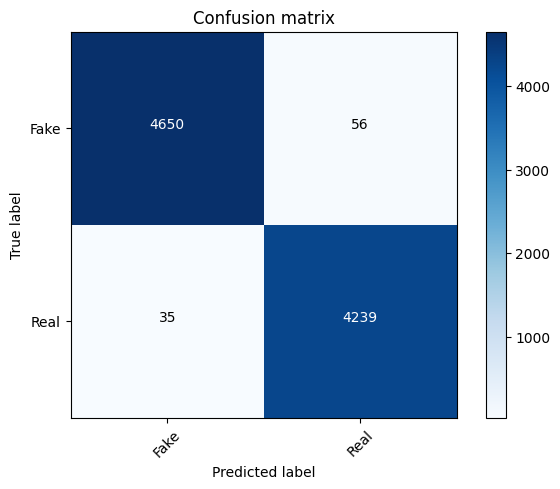

In [39]:
cm = metrics.confusion_matrix(y_test, prediction)
plot_confusion_matrix(cm, classes=['Fake', 'Real'])

# ***Comparison Table***

In [41]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Models to evaluate
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(criterion='entropy', max_depth=20, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, criterion="entropy", random_state=42)
}

# Evaluate models
results = {}
for name, model in models.items():
    pipe = Pipeline([
        ('vect', CountVectorizer()),
        ('tfidf', TfidfTransformer()),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results[name] = [
        round(accuracy_score(y_test, pred)*100, 2),
        round(precision_score(y_test, pred, average='weighted')*100, 2),
        round(recall_score(y_test, pred, average='weighted')*100, 2),
        round(f1_score(y_test, pred, average='weighted')*100, 2)
    ]

# Comparison table
df = pd.DataFrame(results, index=["Accuracy", "Precision", "Recall", "F1 Score"]).T
print(df)


                     Accuracy  Precision  Recall  F1 Score
Logistic Regression     98.88      98.88   98.88     98.88
Decision Tree           99.71      99.71   99.71     99.71
Random Forest           98.99      98.99   98.99     98.99
